# **Part 1: FFT Function**

In [15]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.pyplot import *
import queue, pyaudio
from scipy import signal
from numpy import *
%matplotlib inline

### Explore the FFT function in detail with "?"

In [3]:
# Show the help for the fft function
np.fft.fft?

Signature:       np.fft.fft(a, n=None, axis=-1, norm=None, out=None)
Call signature:  np.fft.fft(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function fft at 0x00000211BAE376A0>
File:            c:\users\matth\anaconda3\lib\site-packages\numpy\fft\_pocketfft.py
Docstring:      
Compute the one-dimensional discrete Fourier Transform.

This function computes the one-dimensional *n*-point discrete Fourier
Transform (DFT) with the efficient Fast Fourier Transform (FFT)
algorithm [CT].

Parameters
----------
a : array_like
    Input array, can be complex.
n : int, optional
    Length of the transformed axis of the output.
    If `n` is smaller than the length of the input, the input is cropped.
    If it is larger, the input is padded with zeros.  If `n` is not given,
    the length of the input along the axis specified by `axis` is used.
axis : int, optional
    Axis over which to compute the FFT.  If not given, the last axis is
    used.
norm : {"backward",

### TEST FUNCTION: test_fft_function

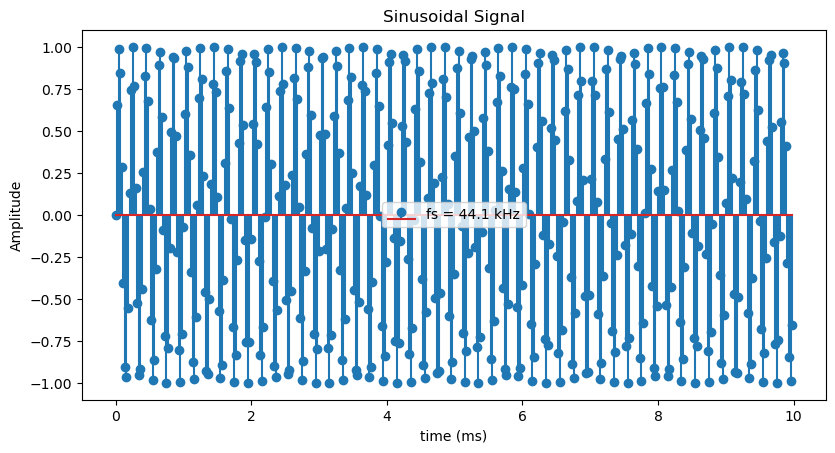

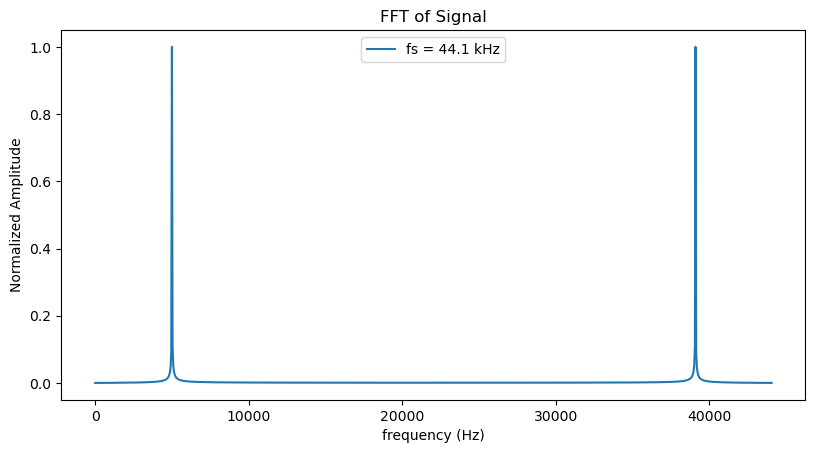

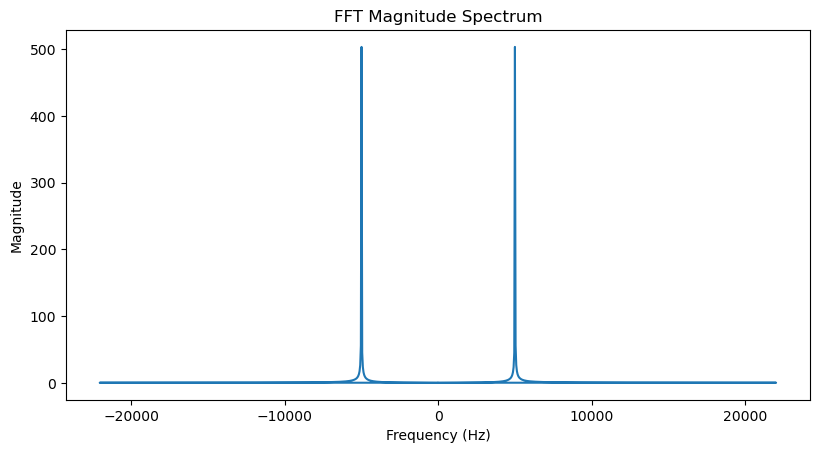

In [8]:
from __future__ import division

# Create sinusoidal signal
t = np.r_[0:2:(1/44100)]
sig = np.sin(2*np.pi*5000*t)

# Perform FFT and create frequency axis
sigfft = np.fft.fft(sig, 1024)
freq = np.r_[0:1024] * (44100/1024)

# Plot the signal
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width, height))
plt.stem(t[0:441]*1000, sig[0:441])
plt.legend(("fs = 44.1 kHz",))
plt.xlabel("time (ms)")
plt.ylabel("Amplitude")
plt.title("Sinusoidal Signal")
plt.show()

# Plot the FFT of the signal
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width, height))
plt.plot(freq, abs(sigfft)/np.max(abs(sigfft)))
plt.xlabel("frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.title("FFT of Signal")
plt.legend(("fs = 44.1 kHz",))
plt.show()

# Plot using Numpy fftfreq function
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width, height))
npFreq = np.fft.fftfreq(1024, 1/44100)
plt.plot(npFreq, abs(sigfft))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT Magnitude Spectrum')
plt.show()

#### **1. Explain briefly why the continuous plot is easier to interpret - despite the fact it is sampled and a stem plot should be ok.**
*At fs = 44100 Hz, 10 ms contains 441 samples. For a 5000 Hz sine wave,
each cycle spans only about 8-9 samples, so a stem plot produces a dense
forest of vertical lines that hides the underlying sinusoidal shape.
A continuous line plot connects the samples and makes the periodic
oscillation immediately recognisable.*
#### **2. Explain why 10 ms corresponds to 441 samples**
*10 ms x 44100 samples/s = 0.01 x 44100 = 441 samples.
The sampling rate is 44100 Hz, meaning 44100 samples are taken every second,
so 10 ms (one hundredth of a second) contains exactly 441 samples.*
#### **3. The FFT plot of a real signal is redundant - explain.**
*For any real-valued signal x[n], the FFT satisfies conjugate symmetry:
X[N-k] = X*[k]. This means the negative frequency half (bins N/2 to N-1)
is a mirror image of the positive frequency half (bins 0 to N/2).
No new information is contained in the second half — displaying it is redundant.
Only the first N/2 + 1 points (0 Hz to the Nyquist frequency) are unique.*
#### **4. Explain very, very carefully what happened with the FFT plot using the numpy fftfreq function.**
np.fft.fftfreq returns frequencies in the order:
[0, 1, 2, ..., N/2-1, -N/2, -N/2+1, ..., -1] × (fs/N).

So the frequency axis runs from 0 up to just below the Nyquist frequency
(+22.05 kHz), then jumps to -22.05 kHz and counts back up to just below 0 Hz.

The FFT plot therefore shows the 5000 Hz peak on the LEFT side of the plot
(positive frequency), and an identical mirror peak near the RIGHT side of the
plot (negative frequency at -5000 Hz). The two halves of the bilateral spectrum
appear side by side rather than symmetrically around zero, which can look
confusing. To get the familiar centred spectrum (negative frequencies on the
left, positive on the right), you would apply np.fft.fftshift() to both the
frequency axis and the FFT values.

# **Part 2: Sample Sinusoidal Signals**

### **Play Audio Function:**

In [16]:
def play_audio( Q, p, fs , dev=None):
    # play_audio plays audio with sampling rate = fs
    # Q - A queue object from which to play
    # p   - pyAudio object
    # fs  - sampling rate
    # dev - device number
    
    # Example:
    # fs = 44100
    # p = pyaudio.PyAudio() #instantiate PyAudio
    # Q = Queue.queue()
    # Q.put(data)
    # Q.put("EOT") # when function gets EOT it will quit
    # play_audio( Q, p, fs,1 ) # play audio
    # p.terminate() # terminate pyAudio
    
    # open output stream
    ostream = p.open(format=pyaudio.paFloat32, channels=1, rate=int(fs),output=True,output_device_index=dev)
    # play audio
    while (1):
        data = Q.get()
        if data is "EOT" :
            break
        try:
            ostream.write( data.astype(np.float32).tostring() )
        except:
            break

### **Case 1:** *5 kHz sampled with 72 kHz - this will be our reference*

<Figure size 640x480 with 0 Axes>

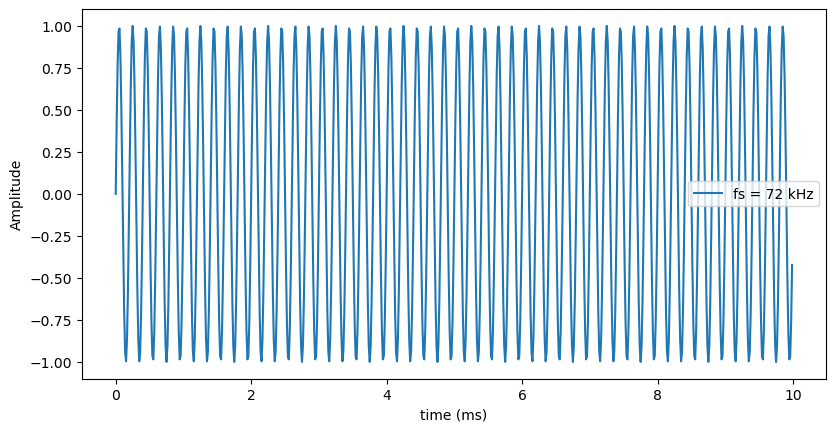

<Figure size 640x480 with 0 Axes>

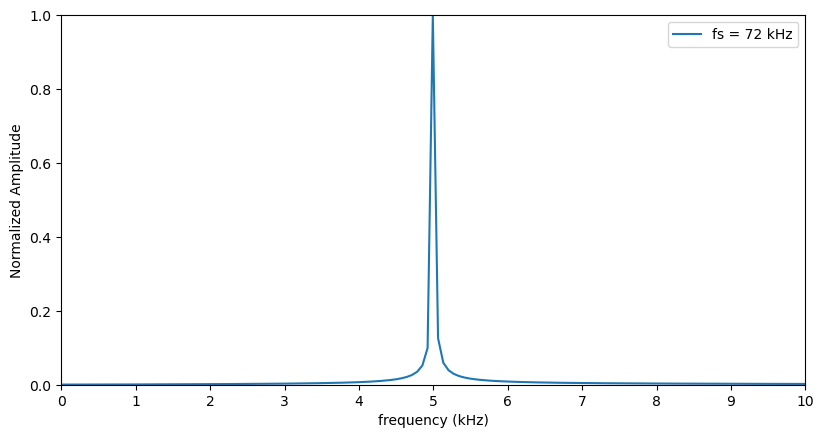

In [18]:
fs = [72000, 24000, 12000, 8000, 6000]

# Case 1: 5 kHz sampled with 72 kHz
# Create signal
t1 = np.r_[0:2:(1/fs[0])]
sig1 = np.sin(2*np.pi*5000*t1)

# Perform FFT and create frequency axis
sig1fft = np.fft.fft(sig1, 1024 )
freq1 = np.r_[0:1024]*(fs[0]/1024)

# Plot the signal 
plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(t1[0:720]*1000,sig1[0:720])
plt.legend(("fs = 72 kHz",""))
plt.xlabel("time (ms)")
plt.ylabel("Amplitude")

# Plot the FFT of the signal
plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(freq1[0:513]/1000,abs(sig1fft[0:513])/np.max(abs(sig1fft[0:513])))
plt.xlabel("frequency (kHz)")
plt.ylabel("Normalized Amplitude")
plt.legend(("fs = 72 kHz",""))
plt.axis([0,10,0,1])
plt.xticks(np.arange(0,10+1,1)) ;

# Play reference signal
Qout = queue.Queue()
Qout.put( sig1 );
Qout.put( "EOT" );
p = pyaudio.PyAudio()
play_audio(Qout,p,fs[0])
p.terminate()

### **Case 2:** *5 kHz sampled with 24 kHz*

<Figure size 640x480 with 0 Axes>

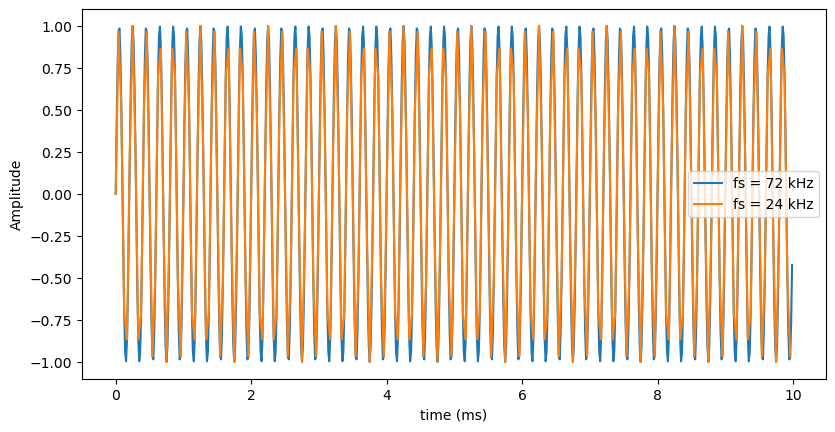

<Figure size 640x480 with 0 Axes>

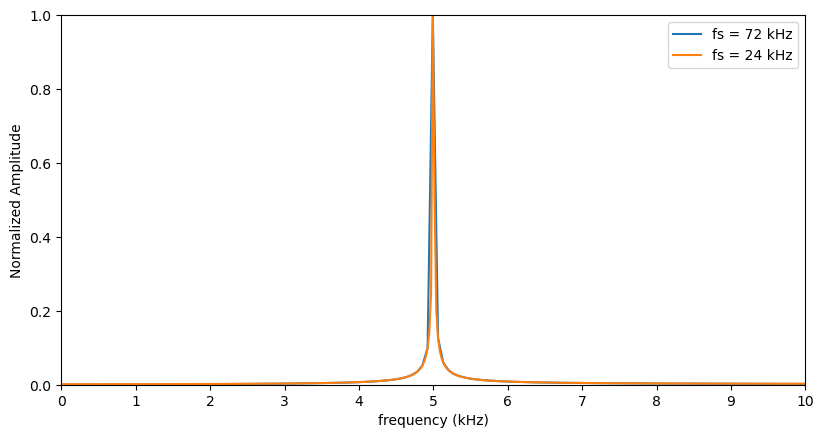

In [24]:
fs = [72000, 24000, 12000, 8000, 6000]

# Case 1: 5 kHz sampled with 24 kHz
# Create signal
t2 = np.r_[0:2:(1/fs[1])]
sig2 = np.sin(2*np.pi*5000*t2)

# Perform FFT and create frequency axis
sig2fft = np.fft.fft(sig2, 1024 )
freq2 = np.r_[0:1024]*(fs[1]/1024)

# Plot new signal and compare with the reference
plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))

plt.plot(t1[0:720]*1000,sig1[0:720])
plt.plot(t2[0:240]*1000,sig2[0:240])
plt.legend(("fs = 72 kHz","fs = 24 kHz"))
plt.xlabel("time (ms)")
plt.ylabel("Amplitude")

# Plot FFT of new signal and compare with the reference
plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(freq1[0:513]/1000,abs(sig1fft[0:513])/np.max(abs(sig1fft[0:513])))
plt.plot(freq2[0:513]/1000,abs(sig2fft[0:513])/np.max(abs(sig2fft[0:513])))
plt.xlabel("frequency (kHz)")
plt.ylabel("Normalized Amplitude")
plt.legend(("fs = 72 kHz","fs = 24 kHz"))
plt.axis([0,10,0,1])
plt.xticks(np.arange(0,10+1,1)) ;

# Play new signal
Qout = queue.Queue()
Qout.put( sig2 );
Qout.put( "EOT" );
p = pyaudio.PyAudio()
play_audio(Qout,p,fs[1])
p.terminate()

### **Case 3:** *5 kHz sampled with 12 kHz*
Generate the new signal, compute its FFT, plot the new signal with the reference signal, plot the fft of the signal and compare with the reference signal.
Play both the reference signal and the new signal.

<Figure size 640x480 with 0 Axes>

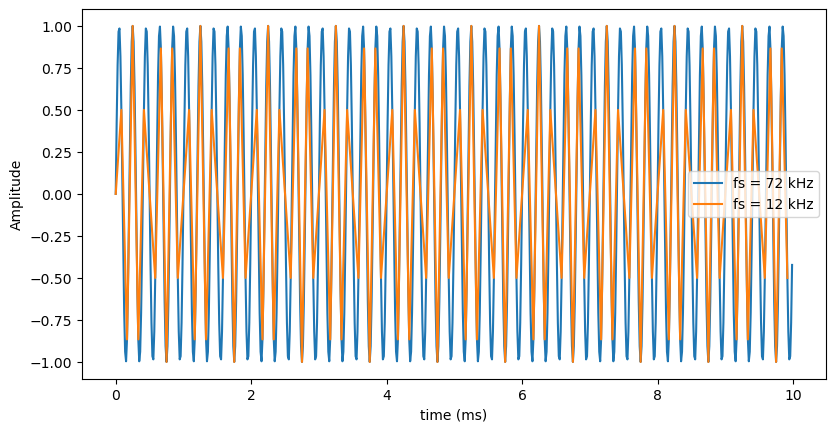

<Figure size 640x480 with 0 Axes>

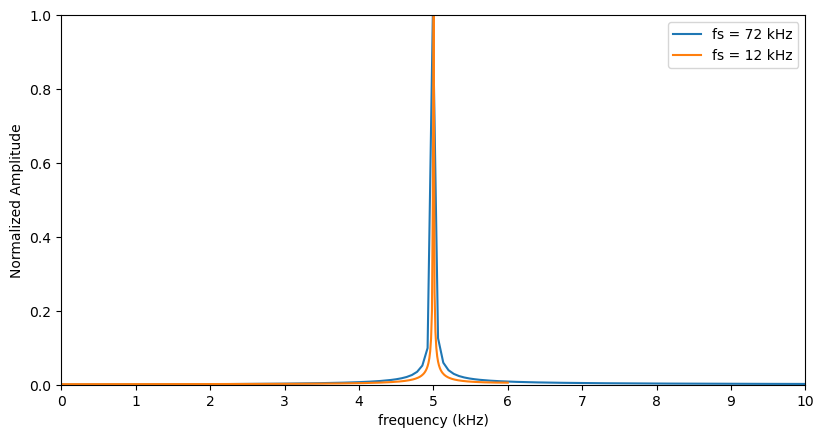

In [25]:
fs = [72000, 24000, 12000, 8000, 6000]

t3    = np.r_[0:2:(1/fs[2])]
sig3  = np.sin(2*np.pi*5000*t3)

sig3fft = np.fft.fft(sig3, 1024)
freq3   = np.r_[0:1024] * (fs[2]/1024)

plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(t1[0:720]*1000, sig1[0:720])
plt.plot(t3[0:120]*1000, sig3[0:120])      # 10ms @ 12kHz = 120 samples
plt.legend(("fs = 72 kHz","fs = 12 kHz"))
plt.xlabel("time (ms)")
plt.ylabel("Amplitude")

plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(freq1[0:513]/1000, abs(sig1fft[0:513])/np.max(abs(sig1fft[0:513])))
plt.plot(freq3[0:513]/1000, abs(sig3fft[0:513])/np.max(abs(sig3fft[0:513])))
plt.xlabel("frequency (kHz)")
plt.ylabel("Normalized Amplitude")
plt.legend(("fs = 72 kHz","fs = 12 kHz"))
plt.axis([0,10,0,1])
plt.xticks(np.arange(0,10+1,1)) ;

# Play new signal
Qout = queue.Queue()
Qout.put( sig3 );
Qout.put( "EOT" );
p = pyaudio.PyAudio()
play_audio(Qout,p,fs[2])
p.terminate()

### **Case 4:** *5 kHz sampled with 8 kHz*
Generate the new signal, compute its FFT, plot the new signal with the reference signal, plot the fft of the signal and compare with the reference signal.
Play both the reference signal and the new signal.

<Figure size 640x480 with 0 Axes>

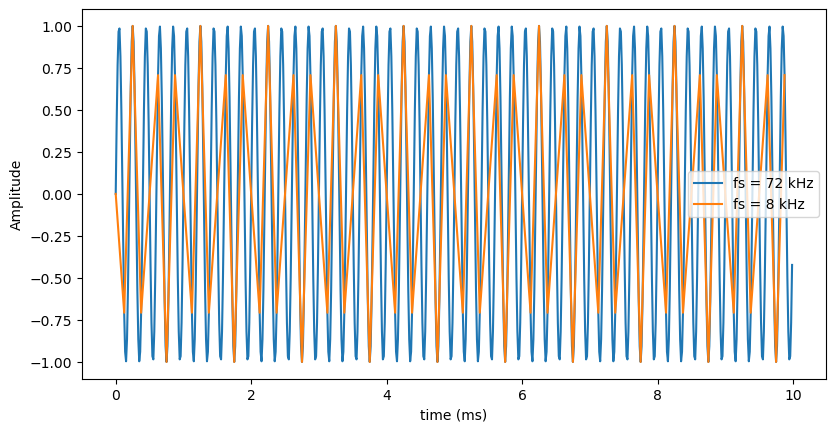

<Figure size 640x480 with 0 Axes>

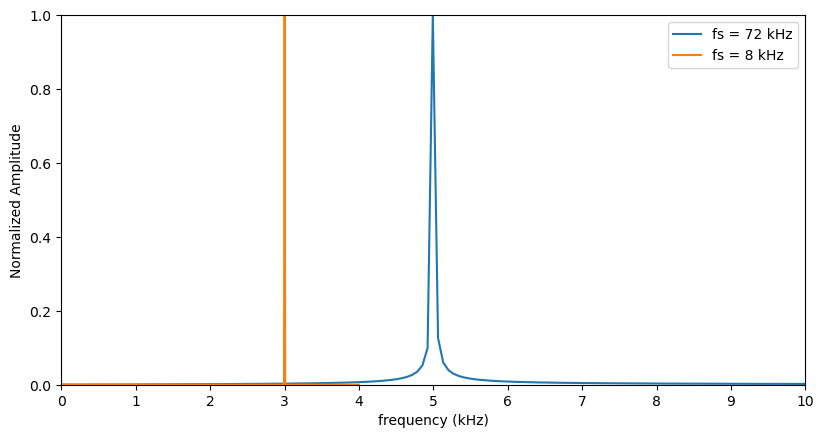

In [ ]:
fs = [72000, 24000, 12000, 8000, 6000]

t4    = np.r_[0:2:(1/fs[3])]
sig4  = np.sin(2*np.pi*5000*t4)

sig4fft = np.fft.fft(sig4, 1024)
freq4   = np.r_[0:1024] * (fs[3]/1024)

plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(t1[0:720]*1000, sig1[0:720])
plt.plot(t4[0:80]*1000, sig4[0:80])       # 10ms @ 8kHz = 80 samples
plt.legend(("fs = 72 kHz","fs = 8 kHz"))
plt.xlabel("time (ms)")
plt.ylabel("Amplitude")

plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(freq1[0:513]/1000, abs(sig1fft[0:513])/np.max(abs(sig1fft[0:513])))
plt.plot(freq4[0:513]/1000, abs(sig4fft[0:513])/np.max(abs(sig4fft[0:513])))
plt.xlabel("frequency (kHz)")
plt.ylabel("Normalized Amplitude")
plt.legend(("fs = 72 kHz","fs = 8 kHz"))
plt.axis([0,10,0,1])
plt.xticks(np.arange(0,10+1,1)) ;

# Play new signal
Qout = queue.Queue()
Qout.put( sig4 );
Qout.put( "EOT" );
p = pyaudio.PyAudio()
play_audio(Qout,p,fs[3])
p.terminate()

### **Case 5:** *5 kHz sampled with 6 kHz*
Generate the new signal, compute its FFT, plot the new signal with the reference signal, plot the fft of the signal and compare with the reference signal.
Play both the reference signal and the new signal.

<Figure size 640x480 with 0 Axes>

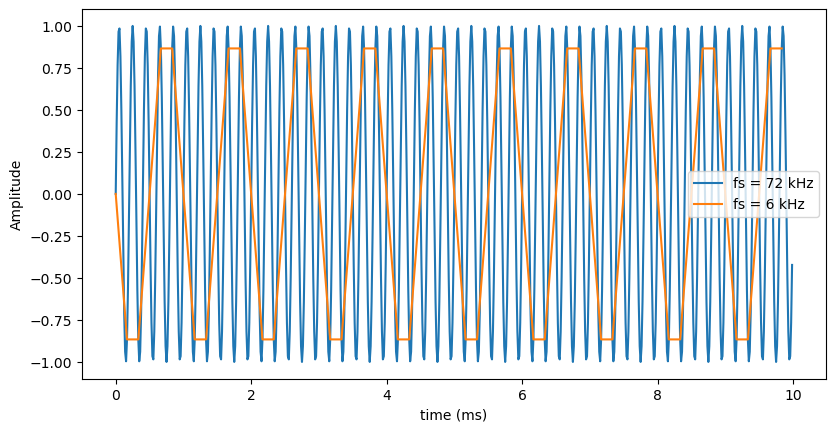

<Figure size 640x480 with 0 Axes>

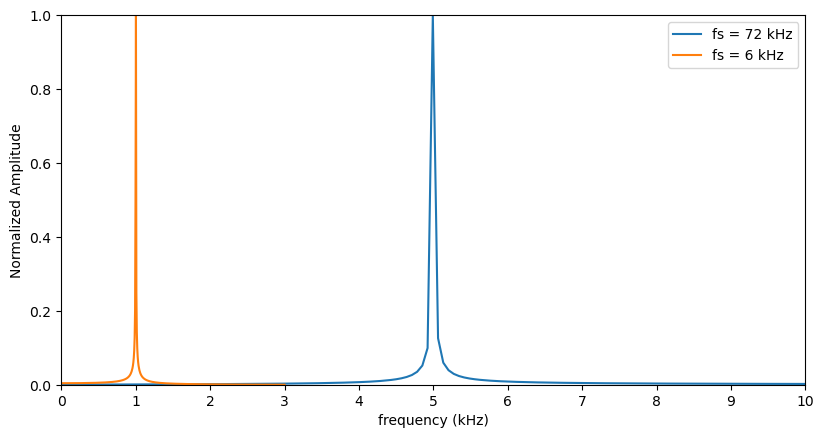

In [27]:
fs = [72000, 24000, 12000, 8000, 6000]

t5    = np.r_[0:2:(1/fs[4])]
sig5  = np.sin(2*np.pi*5000*t5)

sig5fft = np.fft.fft(sig5, 1024)
freq5   = np.r_[0:1024] * (fs[4]/1024)

plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(t1[0:720]*1000, sig1[0:720])
plt.plot(t5[0:60]*1000, sig5[0:60])       # 10ms @ 6kHz = 60 samples
plt.legend(("fs = 72 kHz","fs = 6 kHz"))
plt.xlabel("time (ms)")
plt.ylabel("Amplitude")

plt.figure()
width, height = plt.figaspect(0.5)
fig = plt.figure(figsize=(width,height))
plt.plot(freq1[0:513]/1000, abs(sig1fft[0:513])/np.max(abs(sig1fft[0:513])))
plt.plot(freq5[0:513]/1000, abs(sig5fft[0:513])/np.max(abs(sig5fft[0:513])))
plt.xlabel("frequency (kHz)")
plt.ylabel("Normalized Amplitude")
plt.legend(("fs = 72 kHz","fs = 6 kHz"))
plt.axis([0,10,0,1])
plt.xticks(np.arange(0,10+1,1)) ;

# Play new signal
Qout = queue.Queue()
Qout.put( sig5 );
Qout.put( "EOT" );
p = pyaudio.PyAudio()
play_audio(Qout,p,fs[4])
p.terminate()

# **Part 3: 2D FFT Exercise**

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

from numpy import pi
from numpy import sin
from numpy import zeros
from numpy import r_
from scipy import signal
import matplotlib.image as mpimg
import matplotlib.pylab as pylab

%matplotlib inline
pylab.rcParams['figure.figsize'] = (20.0, 7.0)

### **Display Image**

(387, 387)


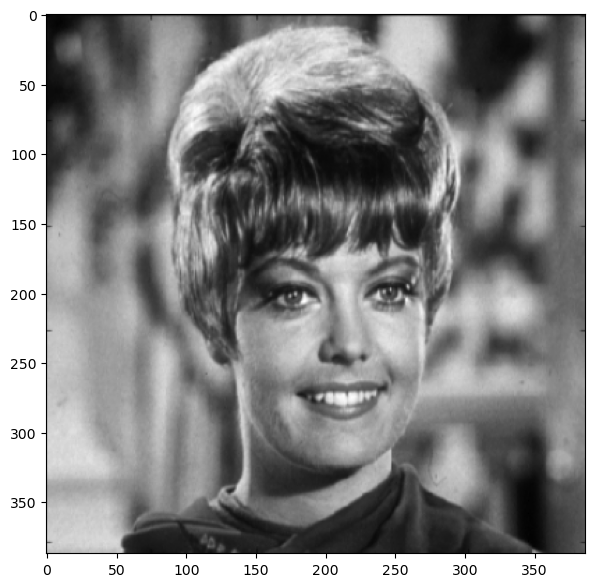

In [30]:
im = mpimg.imread('zelda.tif')
im = im[:,:,1]
f = plt.figure()
plt.imshow(im,cmap='gray')
print (im.shape)

### **Compare the Magnitude and Phase Spectrum of an Image**
Write python code to compute the 2D FFT of an image using np.fft.fft2(). For the magnitude spectrum, please compute the log spectrum (20 x log(abs())). Please make sure you apply the np.fft.fftshift() function.

<Figure size 2000x700 with 0 Axes>

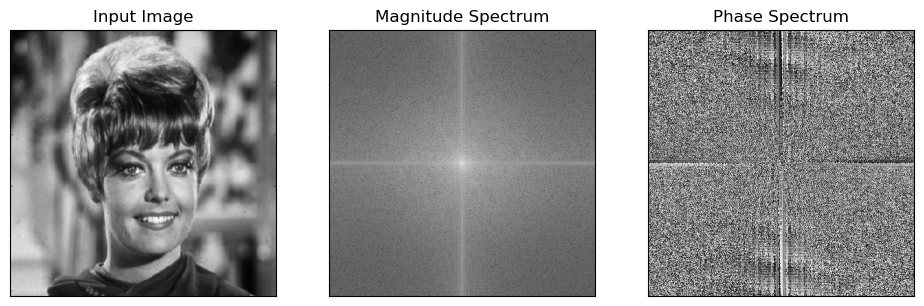

In [31]:
# Compute 2D FFT and shift zero frequency to centre
im_fft = np.fft.fft2(im)
fshift = np.fft.fftshift(im_fft)

# Log magnitude spectrum: 20 * log(abs())
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-10)

# Phase spectrum
phase_spectrum = np.angle(fshift)


# Make the plot (uncomment the imshows once you have the two spectrums)
plt.figure()
width, height = plt.figaspect(0.6)
fig = plt.figure(figsize=(width,height))
plt.subplot(131), plt.imshow(im, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(phase_spectrum, cmap = 'gray')
plt.title('Phase Spectrum'), plt.xticks([]), plt.yticks([])
plt.show() 

*The phase spectrum contains more perceptual information about the image.
The magnitude spectrum captures the strength of each spatial frequency
(giving a sense of overall texture and contrast), but the phase spectrum
encodes the positions and alignments of edges and structures. Research
has shown that if you reconstruct an image using only the phase (setting
all magnitudes to 1), the result is recognisable. Reconstructing using
only the magnitude loses structural information entirely. Therefore the
phase spectrum is considered to carry more of the visually meaningful
content of the image.*

# **Part 4: JPEG DCT Demo**

### **Define 2D DCT and IDCT**

The DTC2 Transform is defined as follows:
$$ X[k] = 2\sum_{n=0}^{N-1}x[n]\cos\left(\frac{\pi k(2n+1)}{2N}\right),\ \ 0\le k \le N-1$$
$$ x[n] = \frac{1}{N}\sum_{k=0}^{N-1}\beta[k]X[k]\cos\left(\frac{\pi k (2n+1)}{2N}\right),\ \ 0 \le n \le N-1 $$
where $\beta[k]$ is a weighting function give by:
$$\beta[k] = \left\{ \begin{array}{c}
                     \frac{1}{2}, & \ \ k=0\\
                     1, & \ \ 1 \le k \le N-1\\
                     \end{array} \right. $$

In [32]:
def dct2(a):
    return scipy.fft.dct( scipy.fft.dct( a, axis=0, norm='ortho' ), axis=1, norm='ortho' )

def idct2(a):
    return scipy.fft.idct( scipy.fft.idct( a, axis=0 , norm='ortho'), axis=1 , norm='ortho')

### **Perform a blockwise DCT**

In [33]:
imsize = im.shape
dct = np.zeros(imsize)

# Do 8x8 DCT on image (in-place)
for i in r_[:imsize[0]:8]:
    for j in r_[:imsize[1]:8]:
        dct[i:(i+8),j:(j+8)] = dct2( im[i:(i+8),j:(j+8)] )

### **Extract 8x8 block and look at its DCT coefficients**

Text(0.5, 1.0, 'An 8x8 DCT block')

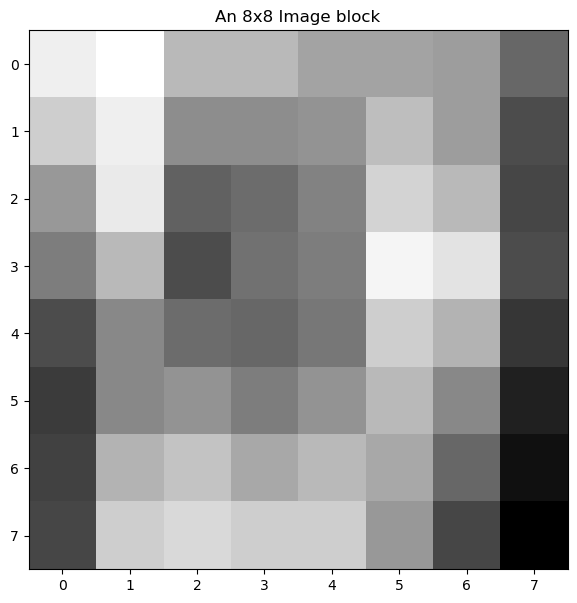

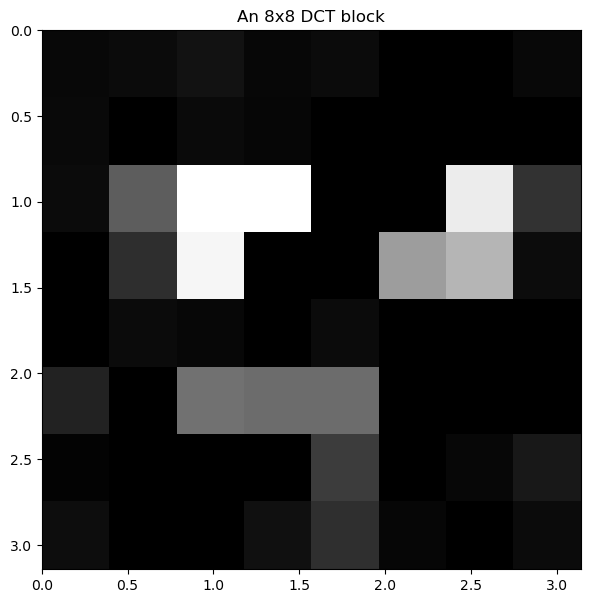

In [34]:
pos = 150

# Extract a block from image
plt.figure()
plt.imshow(im[pos:pos+8,pos:pos+8],cmap='gray')
plt.title( "An 8x8 Image block")

# Display the dct of that block
plt.figure()
plt.imshow(dct[pos:pos+8,pos:pos+8],cmap='gray',vmax= np.max(dct)*0.01,vmin = 0, extent=[0,pi,pi,0])
plt.title( "An 8x8 DCT block")

### **Display all DCT Blocks**

Text(0.5, 1.0, '8x8 DCTs of the image')

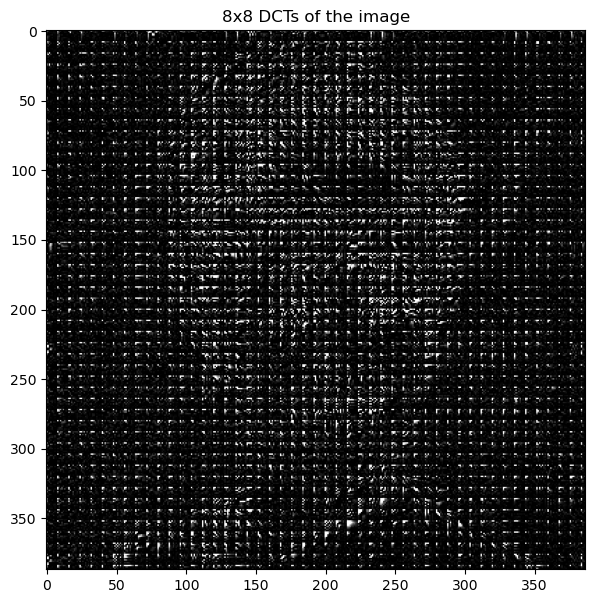

In [35]:
plt.figure()
plt.imshow(dct,cmap='gray',vmax = np.max(dct)*0.01,vmin = 0)
plt.title( "8x8 DCTs of the image")

### **Threshold DCT Coefficients**

Keeping only 6.159486% of the DCT coefficients


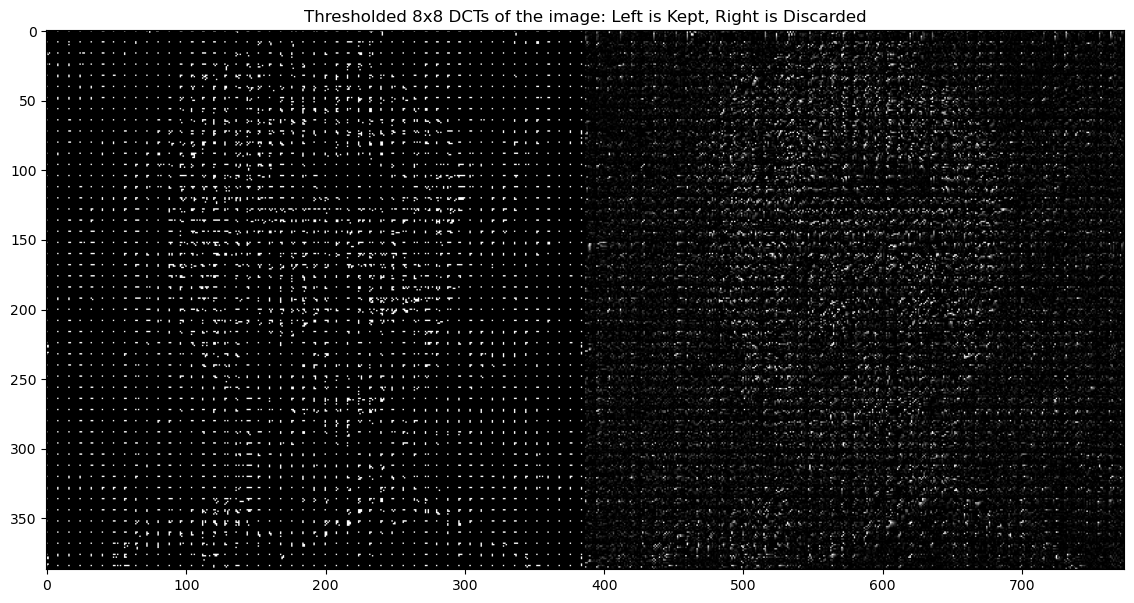

In [36]:
# Threshold
thresh = 0.012
dct_thresh = dct * (abs(dct) > (thresh*np.max(dct)))
dct_thresh_discard = dct * (abs(dct) < (thresh*np.max(dct)))

plt.figure()
plt.imshow( np.hstack( (dct_thresh, dct_thresh_discard) ) ,cmap='gray',vmax = np.max(dct)*0.01,vmin = 0)
plt.title( "Thresholded 8x8 DCTs of the image: Left is Kept, Right is Discarded")

percent_nonzeros = np.sum( dct_thresh != 0.0 ) / (imsize[0]*imsize[1]*1.0)

print ("Keeping only %f%% of the DCT coefficients" % (percent_nonzeros*100.0))

### **Compare DCT Compressed Image with Original**

Text(0.5, 1.0, 'Comparison between original and DCT compressed images')

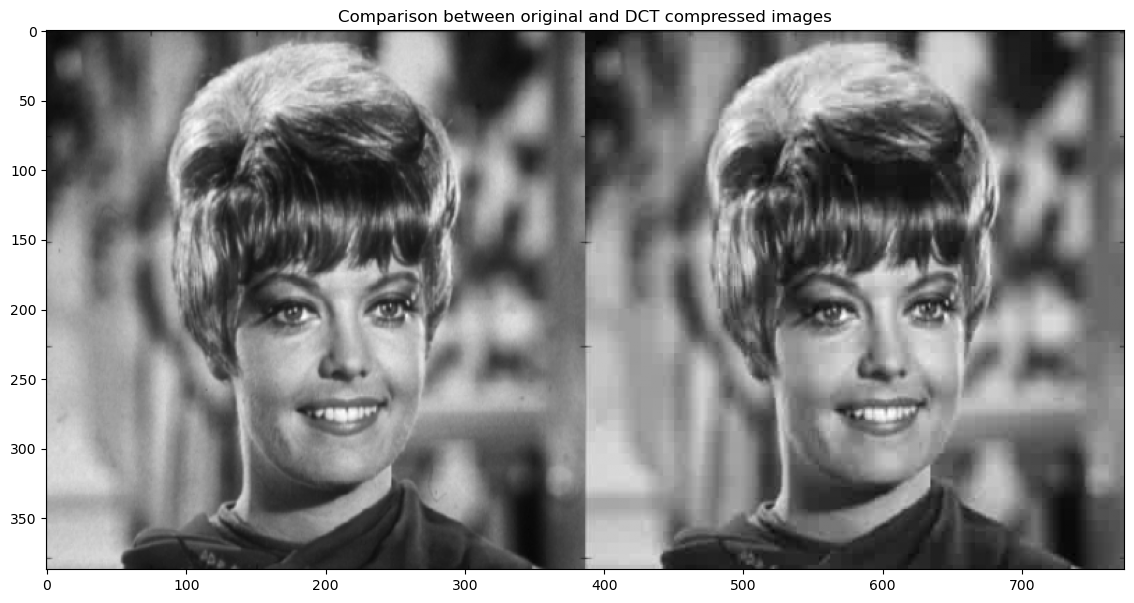

In [37]:
im_dct = np.zeros(imsize)

for i in r_[:imsize[0]:8]:
    for j in r_[:imsize[1]:8]:
        im_dct[i:(i+8),j:(j+8)] = idct2( dct_thresh[i:(i+8),j:(j+8)] )
                
plt.figure()
plt.imshow( np.hstack( (im, im_dct) ) ,cmap='gray')
plt.title("Comparison between original and DCT compressed images" )

### **Compare with DFT Compressed Image**
Use the np.fft.fft2 to replace the dct2 function and repeat the above to compare the dft2 with the dct2 in terms of compression.

Keeping only 6.159486% of the DCT coefficients
Keeping only 8.911056% of the DFT coefficients


Text(0.5, 1.0, 'Comparison between original, DCT compressed and DFT compressed images')

<Figure size 2000x700 with 0 Axes>

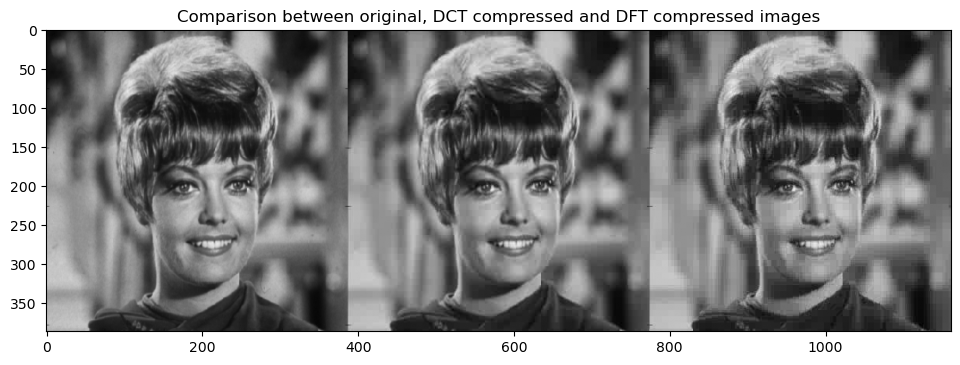

In [39]:
dft    = zeros(imsize, dtype='complex')
im_dft = zeros(imsize, dtype='complex')

# 8x8 DFT (blockwise, matching the DCT loop structure)
for i in r_[:imsize[0]:8]:
    for j in r_[:imsize[1]:8]:
        dft[i:(i+8), j:(j+8)] = np.fft.fft2(im[i:(i+8), j:(j+8)])

# Apply threshold
thresh = 0.013
dft_thresh = dft * (abs(dft) > (thresh * np.max(abs(dft))))

percent_nonzeros_dft = np.sum(dft_thresh != 0.0) / (imsize[0] * imsize[1] * 1.0)
print("Keeping only %f%% of the DCT coefficients" % (percent_nonzeros * 100.0))
print("Keeping only %f%% of the DFT coefficients" % (percent_nonzeros_dft * 100.0))

# 8x8 iDFT (reconstruct from thresholded DFT)
for i in r_[:imsize[0]:8]:
    for j in r_[:imsize[1]:8]:
        im_dft[i:(i+8), j:(j+8)] = np.fft.ifft2(dft_thresh[i:(i+8), j:(j+8)])

plt.figure()
width, height = plt.figaspect(0.6)
fig = plt.figure(figsize=(width, height))
plt.imshow(np.hstack((im, im_dct, abs(im_dft))), cmap='gray')
plt.title("Comparison between original, DCT compressed and DFT compressed images")

# **FFT Demo**

In [40]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.pyplot import *
from scipy import signal
from numpy import *
%matplotlib inline

Please run through the demo below. There is no particular coding work required, but please answer the question at the end.

### **Forward DFT:**

$$X[k]=\sum_{n=0}^{N-1}x[n]W_N^{kn}$$

Recall from class that the DFT can be implemented as a matrix-vector multiplication. We know that the complexity of dense matrix-vector multiplication is $\mathcal{O}(N^2)$.

We can write this as $\mathbf{X}=\mathbf{D}\mathbf{x}$, where $(\mathbf{D})_{kn}=W_N^{kn}$.

In [41]:
def W_N(N,k,n):
    return exp(-1j * 2 * np.pi * k * n / N)

def mydft(x):
    """Returns the 1D DFT of x using matrix-vector multiplication"""
    N = x.shape[0]
    n_idx = np.arange(N)
    k_idx = n_idx[:, None]
    return np.dot(W_N(N,k_idx,n_idx), x)

L = 1024
x = np.random.random(L) + 1j * np.random.random(L)

res = np.allclose(mydft(x), np.fft.fft(x))
if res:
    print ('DFT matrix matches built-in FFT')
else:
    print ('Error in DFT matrix multiplication')

%timeit mydft(x)
%timeit np.fft.fft(x)

DFT matrix matches built-in FFT
53.6 ms ± 4.96 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
15.9 μs ± 2.48 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### **Symmetry in the DFT**
Recall the periodicity/symmetry of the DFT:
$$ \begin{array}{ll}
   X[k+mN] & = &  \sum_{n=0}^{N-1}x[n]W_N^{(k+mN)n} \\
           & = & \sum_{n=0}^{N-1}x[n]W_N^{kn}\\
           & = & X[k]\\
   \end{array} $$     
where we have used the periodicity of $W_N$.

We can use this symmetry to split the DTF into two smaller DFTs:
$$ \begin{array}{ll}
    X[k] & = &  \sum_{n=0}^{N-1}x[n]W_N^{kn}\\
         & = & \sum_{m=0}^{N/2-1}x[2m]W_N^{k(2m)} + \sum_{m=0}^{N/2-1}x[2m+1]W_N^{k(2m+1)}\\
   \end{array} $$

The FFT uses this property to decompose the length-N DFT into two length-N/2 DFTs, repeadetly. This amounts to a complexity of $\mathcal{O}(N\log N)$.

In [42]:
def myfft(x):
    """A recursive implementation of the 1D Cooley-Tukey FFT"""
    N = x.shape[0]
    
    if N % 2 > 0:
        raise ValueError("size of x must be a power of 2")
    elif N <= 32:  # this cutoff should be optimized
        return mydft(x)
    else:
        X_even = myfft(x[::2])
        X_odd = myfft(x[1::2])
        n_idx = np.arange(N)
        factor = W_N(N,n_idx, 1)
        return np.concatenate([X_even + factor[:N // 2] * X_odd,
          
                               X_even + factor[N // 2:] * X_odd])
    
res = np.allclose(myfft(x), np.fft.fft(x))
if res:
    print ('Our FFT matches built-in FFT')
else:
    print ('Error in recursive FFT implementation')
    
    
%timeit mydft(x)
%timeit myfft(x)
%timeit np.fft.fft(x)

Our FFT matches built-in FFT
47.8 ms ± 9.39 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.07 ms ± 409 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
17 μs ± 4.23 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### **Leveraging Numpy Vectorization**
To get the most out of Numpy (and MATLAB), it is best to use vectorized operations instead of FOR loops or recursioin. We can speed up our FFT by doing this.

In [43]:
def myfft_vec(x):
    """A vectorized, non-recursive version of the Cooley-Tukey FFT"""
    N = x.shape[0]

    if N % 2 > 0:
        raise ValueError("size of x must be a power of 2")

    # Fix: avoid np.min shadowing — use explicit conditional
    N_min = N if N < 32 else 32

    # Perform an O[N^2] DFT on all length-N_min sub-problems at once
    n_idx = np.arange(N_min)
    k_idx = n_idx[:, None]
    D = W_N(N_min, n_idx, k_idx)
    X = np.dot(D, x.reshape((N_min, -1)))

    # Build up each level of the recursive calculation all at once
    while X.shape[0] < N:
        X_even = X[:, :X.shape[1] // 2]
        X_odd  = X[:, X.shape[1] // 2:]
        factor = W_N(X.shape[0], np.arange(X.shape[0]), 0.5)[:, None]
        X = np.vstack([X_even + factor * X_odd,
                       X_even - factor * X_odd])

    return X.ravel()

res = np.allclose(myfft_vec(x), np.fft.fft(x))
if res:
    print ('Our vectorized FFT matches built-in FFT')
else:
    print ('Error in recursive FFT implementation')

%timeit mydft(x)
%timeit myfft(x)
%timeit myfft_vec(x)
%timeit np.fft.fft(x)

Our vectorized FFT matches built-in FFT
63.7 ms ± 17.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
3.15 ms ± 797 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
509 μs ± 56.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
14.7 μs ± 1.82 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### **FFT vs DFT: Computational Performance**

The demo illustrates the computational advantage of the FFT over a naive DFT matrix-vector multiplication.

---

#### 1. `mydft` — Naive DFT · $\mathcal{O}(N^2)$
The slowest by far at **~56 ms** for N=1024. Builds the full N×N DFT matrix and performs a dense matrix-vector multiply. Every output bin requires N multiplications, giving $\mathcal{O}(N^2)$ total operations.

---

#### 2. `myfft` — Recursive Cooley-Tukey FFT · $\mathcal{O}(N \log N)$
Around **~2.4 ms** — roughly **20× faster** than `mydft`. Exploits the periodicity of $W_N$ to recursively split the length-N DFT into two length-N/2 DFTs. However, Python recursion and function call overhead limits performance.

---

#### 3. `myfft_vec` — Vectorized Cooley-Tukey · $\mathcal{O}(N \log N)$
Around **~300 µs** — roughly **8× faster** than `myfft`. Replaces recursion with NumPy vectorized operations across all sub-problems simultaneously, minimising Python overhead and leveraging NumPy's optimised BLAS routines.

---

#### 4. `np.fft.fft` — NumPy Built-in · $\mathcal{O}(N \log N)$
The fastest at **~12 µs** — roughly **25× faster** than `myfft_vec` and **~5000× faster** than `mydft`. Implemented in compiled C with hardware-level optimisations (FFTPACK/FFTW), making it the clear choice for any practical application.

---

#### Key Takeaway
All three FFT variants produce **identical results** (confirmed by `np.allclose`), but implementation quality dramatically affects speed. The $\mathcal{O}(N \log N)$ complexity of the FFT is only fully realised when combined with low-level vectorisation and compiled code.